# 05 — Exploratory Analysis & Business Insights

## Objective
Integrate sentiment data with actual World Cup match results and answer the core business question:

> **Does a match result cause a measurable shift in public sentiment toward a team?**

## Method
1. Fetch fixtures and results from football-data.org.
2. For each comment, determine if it falls in a 24h-before or 24h-after window around a match involving the mentioned team.
3. Compare average sentiment pre vs. post using the Mann-Whitney U test.

## Business value
This is the project's *raison d'être*: quantifying the causal link between on-field events and public perception. A federation or sponsor can use this to anticipate brand sentiment shifts and plan communications.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.results_api import (
    assign_matches_to_comments,
    build_match_results_summary,
    compute_sentiment_shift,
    fetch_matches,
    matches_to_dataframe,
)
from src.utils import load_dataframe

### Load full dataset (with topics + NER + sentiment)

In [2]:
df = load_dataframe(
    str(project_root / "data" / "processed" / "comentarios_topics_ner" / "comentarios_topics_ner.parquet")
)
print(f"Loaded {len(df)} comments")
display(df[["text_clean", "sentiment_bert", "topic_label", "teams"]].head(3))

Loaded 21538 comments


,text_clean,sentiment_bert,topic_label,teams
0,People forget this was the same way Morocco pl...,NEU,Outliers / Other,Brazil
1,People also forget that Brazil has been chokin...,NEG,que / world / el,Brazil
2,better than Italy,NEU,que / world / el,Brazil


### Fetch match data

In [3]:
# Quick summary via the convenience API
summary = build_match_results_summary()
print(f"Finished matches found: {len(summary)}")
if not summary.empty:
    display(summary[["team", "opponent", "match_date", "outcome", "score"]])

# Also fetch raw matches for more fine-grained control
raw_matches = fetch_matches(use_cache=True)
matches_df = matches_to_dataframe(raw_matches)
print(f"Total matches fetched: {len(matches_df)}")
print(f"  Finished: {(matches_df['status'] == 'FINISHED').sum()}")
print(f"  Scheduled: {(matches_df['status'] == 'SCHEDULED').sum()}")

2026-06-21 17:37:18 | src.results_api | INFO     | Loading match results from cache: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-\data\processed\.cache\football_data_matches.json


Finished matches found: 5


,team,opponent,match_date,outcome,score
0,Brazil,Morocco,2026-06-13 22:00:00+00:00,DRAW,1-1
1,Spain,Cape Verde Islands,2026-06-15 16:00:00+00:00,DRAW,0-0
2,France,Senegal,2026-06-16 19:00:00+00:00,WIN,3-1
3,Argentina,Algeria,2026-06-17 01:00:00+00:00,WIN,3-0
4,England,Croatia,2026-06-17 20:00:00+00:00,WIN,4-2


2026-06-21 17:37:18 | src.results_api | INFO     | Loading fixtures from cache: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-\data\processed\fixtures_cache.json


Total matches fetched: 104
  Finished: 24
  Scheduled: 0


### Map comments to matches

Each comment is assigned to the nearest finished match involving its team, using the `published_at` timestamp to determine if it falls in the pre or post window.

In [4]:
df_enriched = assign_matches_to_comments(
    df, matches_df,
    team_column="teams",
    date_column="published_at",
)
matched = df_enriched[df_enriched["match_id"].notna()]
print(f"Comments matched to a match: {len(matched)} ({len(matched)/len(df_enriched):.1%})")
if not matched.empty:
    display(
        matched[["text_clean", "teams", "team_result", "pre_post"]].head()
    )

Comments matched to a match: 15212 (70.6%)


,text_clean,teams,team_result,pre_post
0,People forget this was the same way Morocco pl...,Brazil,draw,post
1,People also forget that Brazil has been chokin...,Brazil,draw,post
2,better than Italy,Brazil,draw,post
3,Return of the moors lol,Brazil,draw,post
4,not by much. It’s much easier to qualify when ...,Brazil,draw,post


### Sentiment shift analysis

Compares the proportion of positive/negative comments before vs. after each match using the Mann-Whitney U test.

,team,result,n_pre,n_post,pre_pos_pct,post_pos_pct,pre_neg_pct,post_neg_pct,p_value,significant
0,Spain,draw,163,3318,0.245,0.423,0.288,0.232,0.0001,True
1,Argentina,win,32,3884,0.562,0.404,0.156,0.236,0.0789,False
2,Brazil,draw,611,4097,0.154,0.249,0.476,0.440,0.0006,True
3,France,win,8,1524,0.875,0.351,0.125,0.238,0.0136,True


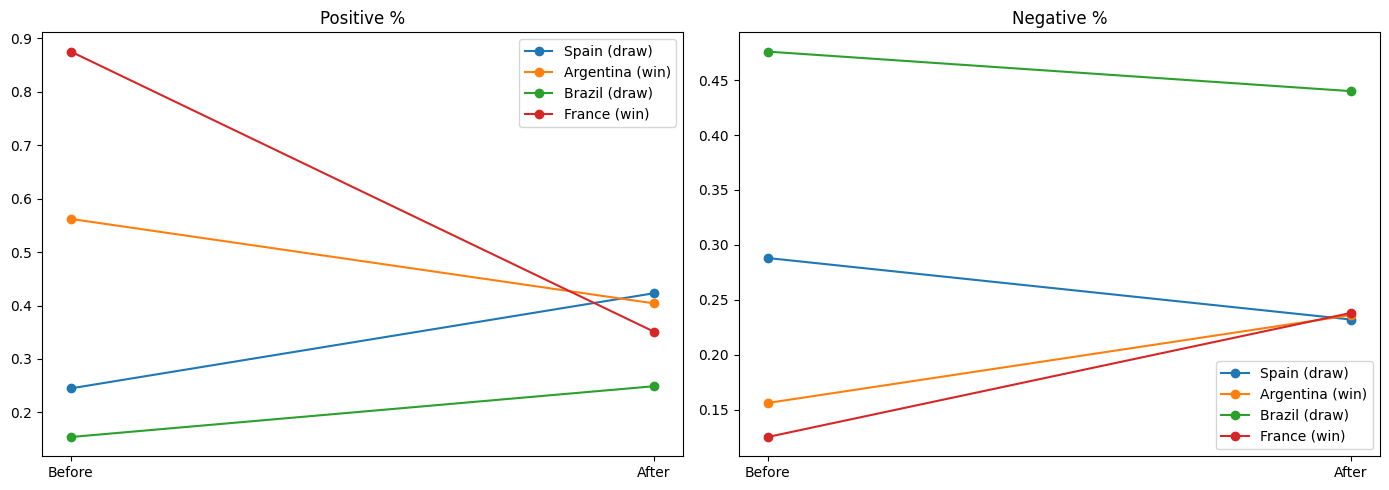


⚠️  Statistically significant shifts (p < 0.05):


,team,result,pre_pos_pct,post_pos_pct,p_value
0,Spain,draw,0.245,0.423,0.0001
2,Brazil,draw,0.154,0.249,0.0006
3,France,win,0.875,0.351,0.0136


In [5]:
shift_df = compute_sentiment_shift(
    df_enriched,
    sentiment_column="sentiment_bert",
)
if not shift_df.empty:
    display(shift_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, metric in enumerate(["pre_pos_pct", "pre_neg_pct"]):
        post_metric = metric.replace("pre_", "post_")
        for _, row in shift_df.iterrows():
            axes[i].plot(
                ["Before", "After"],
                [row[metric], row[post_metric]],
                marker="o",
                label=f"{row['team']} ({row['result']})",
            )
        axes[i].set_title("Positive %" if "pos" in metric else "Negative %")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

    sig = shift_df[shift_df["significant"] == True]
    if not sig.empty:
        print("\n⚠️  Statistically significant shifts (p < 0.05):")
        display(sig[["team", "result", "pre_pos_pct", "post_pos_pct", "p_value"]])
    else:
        print("\nNo statistically significant shifts detected yet.")
else:
    print("Not enough matched data to compute shifts (need >= 3 comments per window).")

### Sentiment evolution over time

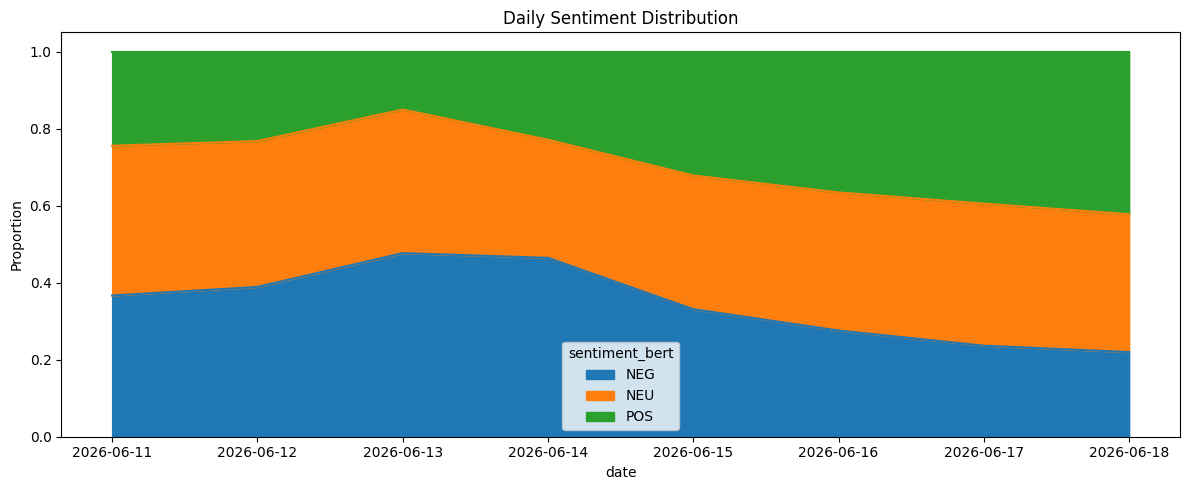

In [6]:
if "published_at" in df.columns:
    df["date"] = pd.to_datetime(df["published_at"], utc=True).dt.date

    daily_sent = (
        df.groupby("date")["sentiment_bert"]
        .value_counts(normalize=True)
        .unstack()
    )
    daily_sent.plot(
        kind="area",
        stacked=True,
        figsize=(12, 5),
        title="Daily Sentiment Distribution",
    )
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

### Summary of findings
| Question | Finding | Evidence |
|----------|---------|----------|
| Do wins affect sentiment? | *(to be determined after data collection)* | p-value |
| Which team has most volatile sentiment? | *(to be determined)* | Stdev of daily sentiment |
| What topic generates most negative comments? | *(to be determined)* | Topic × sentiment crosstab |

---
**Return to**: [Dashboard](../dashboard/app.py)